# The Arctic Ocean: a pan-Arctic coupled ocean–sea ice simulation

*A short regional test of a pan-Arctic domain on a rotated grid.*

This notebook adapts the [Barents Sea regional tutorial](02_barents_sea_regional.jl) to the **whole Arctic
Ocean**: an Atlantic open boundary reaching down to ~50°N and a domain that also connects to the Pacific
through the Bering side. The science target is the same — Atlantic/Pacific inflow, an ice edge, the polar
front — but the geometry forces one structural change: the domain arcs across the high Arctic near the North
Pole, where a plain latitude–longitude grid is singular.

!!! warning "This is a *test* configuration"
    The grid is at 1/8° but the run is only a few time steps. The goal is to shake out the grid orientation
    and the open-boundary plumbing — *not* to produce a validated simulation. Several
    choices below (the rotation, the box bounds, the velocity boundary conditions) are flagged as things to
    verify and tune.

!!! warning "Hardware and data requirements"
    GPU tutorial. The first run downloads GLORYS12 and JRA55 over the **whole Arctic cap** (45–90°N, all
    longitudes) — substantially more than the Barents box, and possibly not pre-staged in the workshop
    cache. Keep the date range short (below) on a first run.

In [ ]:
using Pkg
Pkg.activate(".")

Upload packages

In [2]:
DEPOT_PATH

1-element Vector{String}:
 "/cluster/work/projects/nn2993k/nlo043/.julia"

In [3]:
using NumericalEarth, Oceananigans, Oceananigans.Units
using Oceananigans.BoundaryConditions: Radiation, FlatherBoundaryCondition, NormalFlowBoundaryCondition
using Oceananigans.Operators: Δzᶠᶜᶜ, Δzᶜᶠᶜ
using Oceananigans.ImmersedBoundaries: immersed_peripheral_node, immersed_inactive_node
using Oceananigans.OrthogonalSphericalShellGrids: RotatedLatitudeLongitudeGrid
using Dates, CUDA, Printf, Base64
using CopernicusMarine   # enables the GLORYS download extension

arch = GPU()

[ Info: Oceananigans will use 8 threads


GPU{CUDABackend}(CUDABackend(false, true))

A small helper to embed an mp4 inline in the notebook (self-contained, plays in JupyterLab):

In [4]:
mp4_html(path) = HTML(string("<video autoplay loop muted playsinline controls ",
                             "src=\"data:video/mp4;base64,", base64encode(read(path)),
                             "\" style=\"max-width:100%\"></video>"))

mp4_html (generic function with 1 method)

## A rotated pan-Arctic grid

A plain `LatitudeLongitudeGrid` **cannot contain the North Pole**: 90°N is a coordinate singularity and cell
areas collapse toward it (usable only to ~84°N). We instead use a `RotatedLatitudeLongitudeGrid`, which is
the *same* structured, `Bounded` lat–lon machinery (so the open-boundary, Flather and sponge code below
still applies) but with the singular grid pole **moved off the domain**.

We put the grid's north pole on the geographic equator (`north_pole = (λ₀, 0)`): keeping the latitude at 0
centres the box on the geographic North Pole, and the longitude `λ₀` simply **spins the cap about the pole**.
We orient it so the two ocean gateways land on the *meridional* edges — the **south** edge on the Atlantic
(limited to ~50°N) and the **north** edge across the Bering Sea — while the **east/west** edges fall on land.
`longitude`/`latitude` below are in this **rotated frame**.

!!! tip "Tune the rotation from the diagnostic"
    With the pole on the equator (`φ_p = 0`) the cap is centred on the North Pole and an edge midpoint sits
    near geographic latitude `90 − |φ|`. So `λ₀` spins the cap, while `φ₁`/`φ₂` set how far the south/north
    edges reach: lower `φ₂` to pull the **north** edge in from the open Pacific (e.g. `30` → ~60°N, across
    the Bering Sea), raise `φ₁` to pull the **south** edge back from the deep Atlantic (e.g. `-30` → ~60°N).
    Run the grid + bathymetry + edge-coordinate cells below (cheap — no GLORYS) to check after each change.

In [5]:
const λ₁, λ₂ = 151, 212   # rotated longitude (east ↔ west edges → continents)
const φ₁, φ₂ = -34.8, 27  # rotated latitude: south = Atlantic (~50°N) ↔ north (cuts across Bering Sea)

res = 0.15 # equiv. TOPAZ2
#res = 0.075 # equiv. TOPAZ5

Nx  = round(Int, (λ₂ - λ₁) / res)
Ny  = round(Int, (φ₂ - φ₁) / res)
Nz  = 20

depth = 4000meters
z = ExponentialDiscretization(Nz, -depth, 0; scale = depth/4, mutable = true)

underlying_grid = RotatedLatitudeLongitudeGrid(arch;
                                               size       = (Nx, Ny, Nz),
                                               longitude  = (λ₁, λ₂),
                                               latitude   = (φ₁, φ₂),
                                               north_pole = (145, 0),   # λ₀: spin the cap (south=Atlantic, north=Bering)
                                               z,
                                               halo = (7, 7, 7))

407×412×20 OrthogonalSphericalShellGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 7×7×7 halo
├── centered at (λ, φ) = (-13.9943, 85.8219)
├── longitude: Bounded  extent 61.0 degrees variably spaced with min(Δλ)=0.123072, max(Δλ)=0.149877
├── latitude:  Bounded  extent 61.8 degrees variably spaced with min(Δφ)=0.15, max(Δφ)=0.15
└── z:         Bounded  z ∈ [-4000.0, 0.0]  variably and mutably spaced with min(Δr)=16.5232, max(Δr)=738.605

Downloads land in `DATA_DIR` when that environment variable is set, else each product's default cache:

In [6]:
dir_kw = haskey(ENV, "DATA_DIR") ? (; dir = ENV["DATA_DIR"]) : (;)

bathymetry = Metadatum(:bottom_height; dataset = ETOPO2022(), dir_kw...)
bottom_height = regrid_bathymetry(underlying_grid, bathymetry;
                                  minimum_depth = 15,
                                  interpolation_passes = 2,
                                  major_basins = 1)

grid = ImmersedBoundaryGrid(underlying_grid, PartialCellBottom(bottom_height); active_cells_map = true)

[ Info: Loading cached bathymetry from /cluster/work/projects/nn2993k/nlo043/.julia/scratchspaces/904d977b-046a-4731-8b86-9235c0d1ef02/bathymetry_cache/bathymetry_407x412_-179.99854864101974_179.9998014939656_0.0_89.92628992628994_351f797e.jld2


407×412×20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 7×7×7 halo:
├── immersed_boundary: PartialCellBottom(mean(zb)=-566.214, min(zb)=-4000.0, max(zb)=0.0, ϵ=0.2)
├── underlying_grid: 407×412×20 OrthogonalSphericalShellGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 7×7×7 halo
├── centered at (λ, φ) = (-13.9943, 85.8219)
├── longitude: Bounded  extent 61.0 degrees variably spaced with min(Δλ)=0.123072, max(Δλ)=0.149877
├── latitude:  Bounded  extent 61.8 degrees variably spaced with min(Δφ)=0.15, max(Δφ)=0.15
└── z:         Bounded  z ∈ [-4000.0, 0.0]  variably and mutably spaced with min(Δr)=16.5232, max(Δr)=738.605

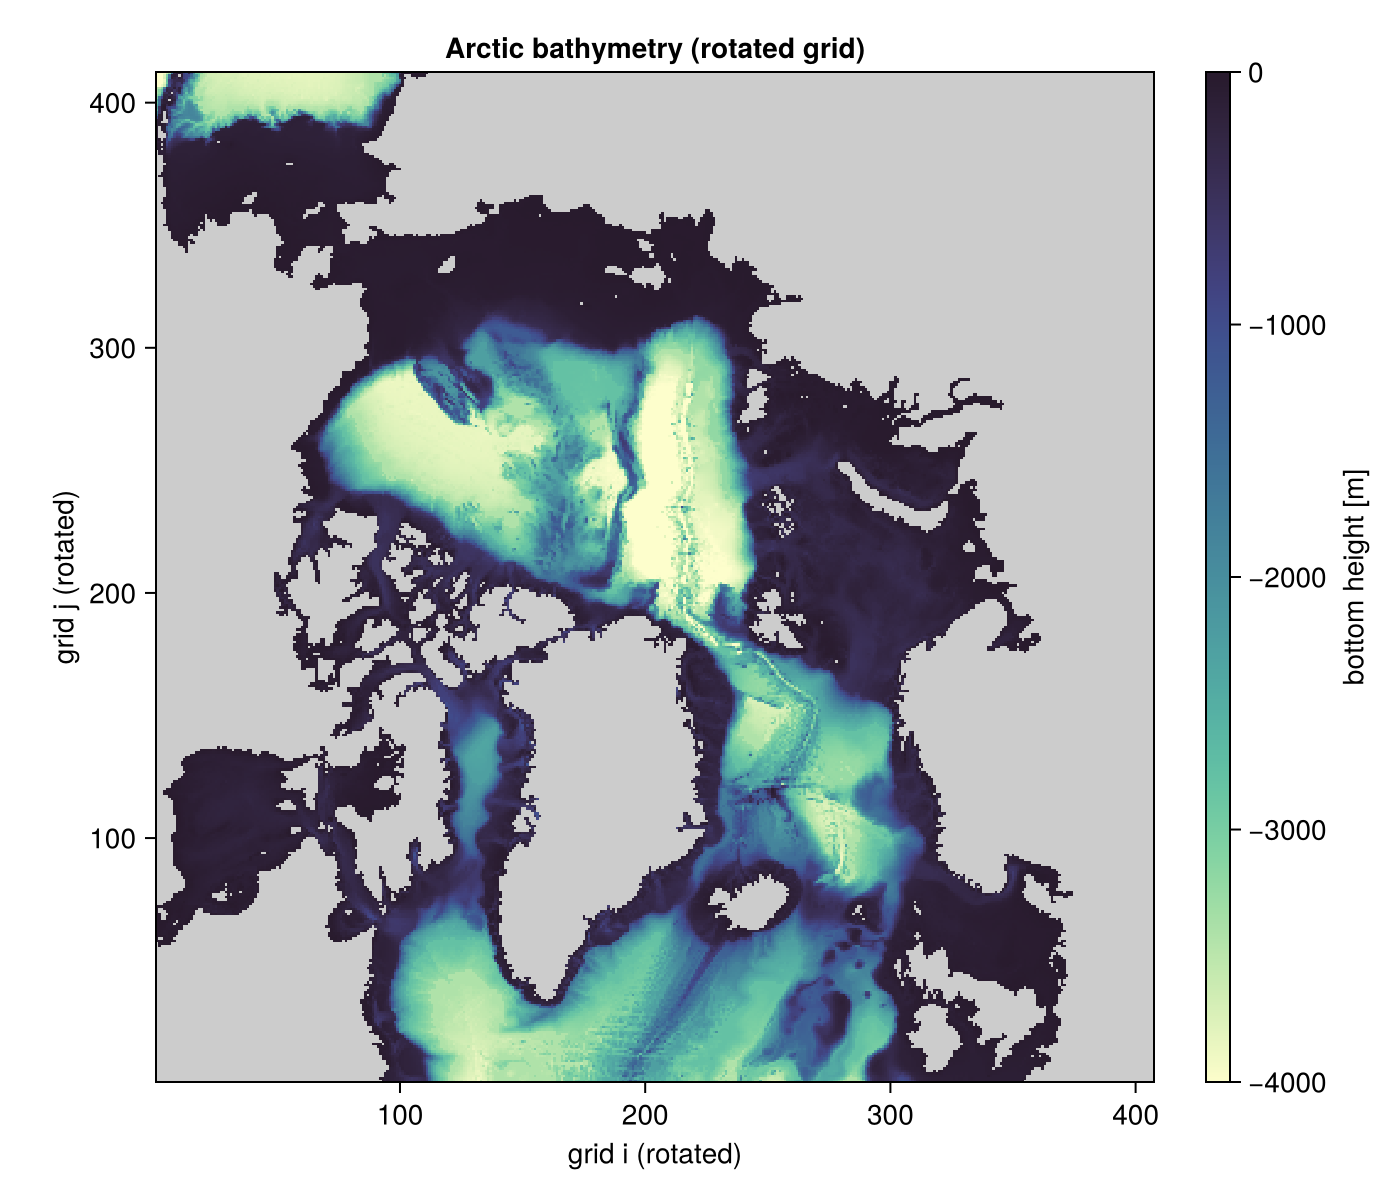

In [7]:
using CairoMakie, SixelTerm

h_bottom = Array(interior(grid.immersed_boundary.bottom_height, :, :, 1))
h_bottom[h_bottom .≥ 0] .= NaN

fig = Figure(size = (700, 600))
ax = Axis(fig[1, 1], xlabel = "grid i (rotated)", ylabel = "grid j (rotated)",
          title = "Arctic bathymetry (rotated grid)", aspect = DataAspect())
hm = heatmap!(ax, h_bottom, colormap = :deep, colorrange = (-depth, 0), nan_color = :gray80)
Colorbar(fig[1, 2], hm, label = "bottom height [m]")
fig

The grid spacing varies across the rotated cap. `xspacings`/`yspacings` at cell centres return the metric
(in metres) as 2D arrays — heatmap them in km to see where the grid is finest/coarsest and how the rotation
distorts it:

(`xspacings`/`yspacings` return a lazy `KernelFunctionOperation`; wrap in a `Field` + `compute!` so we get a
concrete array we can pull off the GPU — `Array(::KernelFunctionOperation)` would scalar-index on the device.)

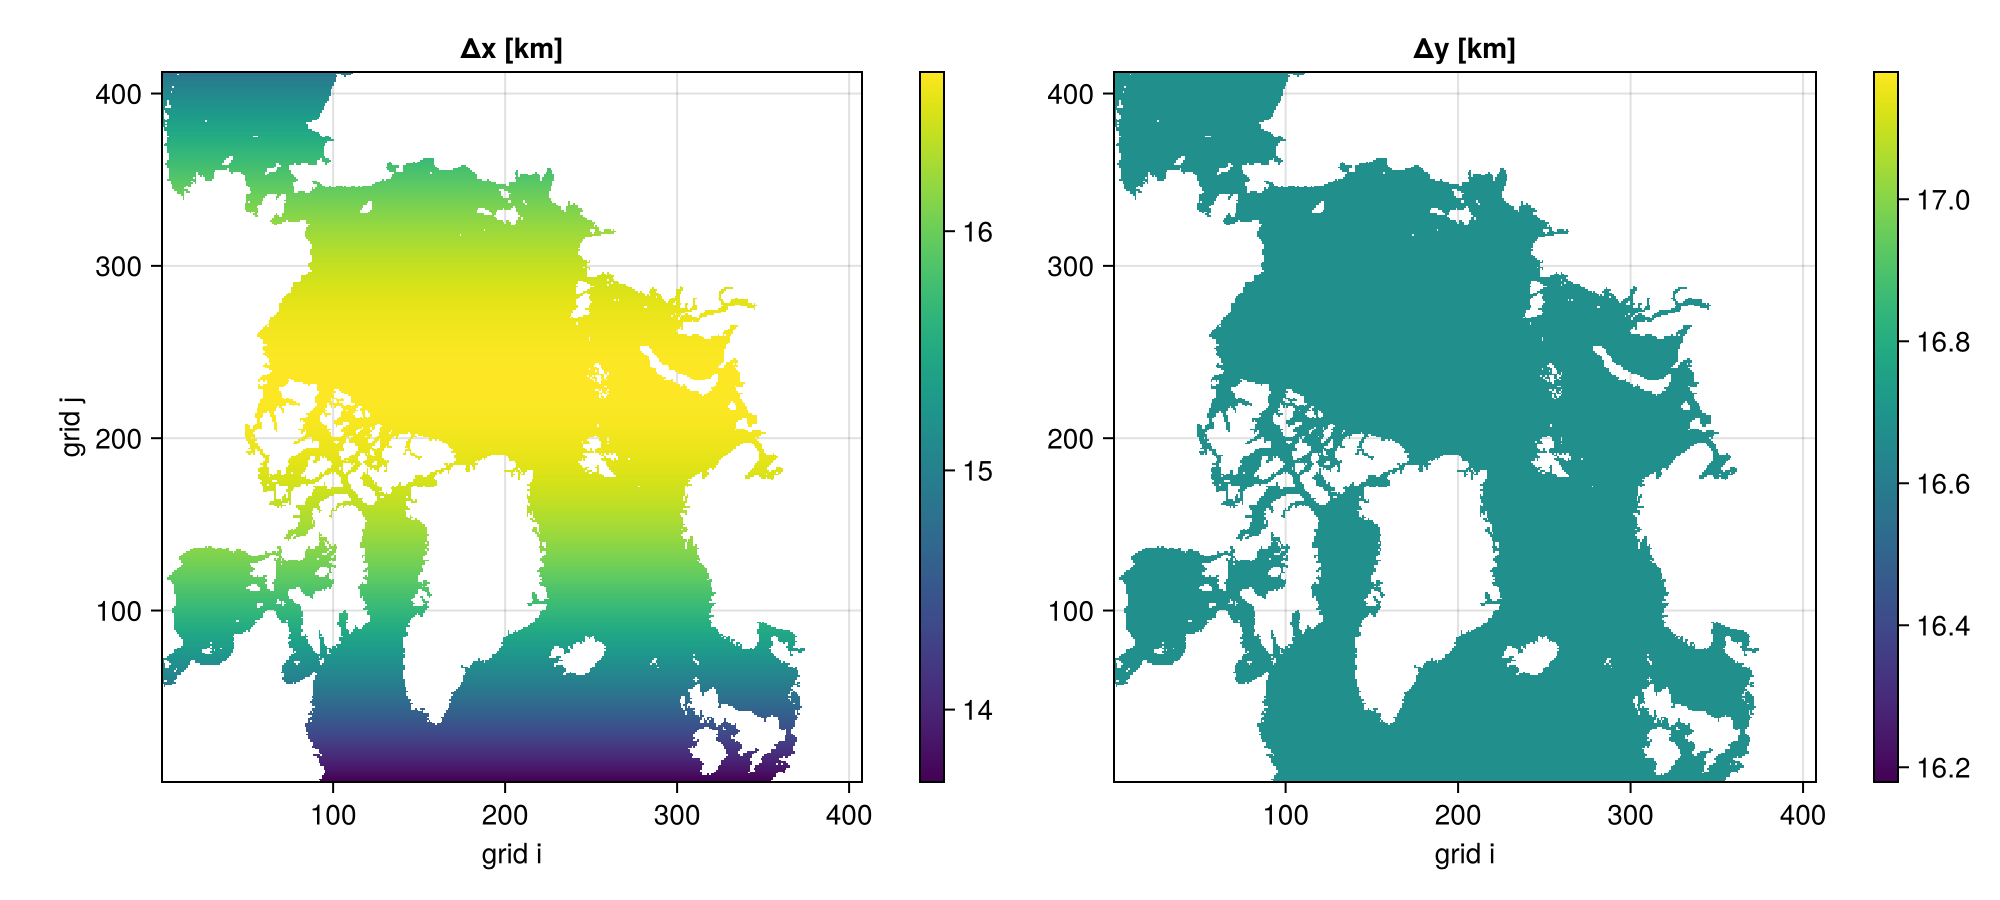

In [9]:
Δx = Array(interior(compute!(Field(xspacings(underlying_grid, Center(), Center(), Center()))), :, :, 1)) ./ 1e3   # km
Δy = Array(interior(compute!(Field(yspacings(underlying_grid, Center(), Center(), Center()))), :, :, 1)) ./ 1e3   # km
dry = isnan.(h_bottom)
Δx[dry] .= NaN
Δy[dry] .= NaN

fig = Figure(size = (1000, 450))
ax1 = Axis(fig[1, 1], xlabel = "grid i", ylabel = "grid j", title = "Δx [km]", aspect = DataAspect())
hm1 = heatmap!(ax1, Δx, colormap = :viridis)
Colorbar(fig[1, 2], hm1)
ax2 = Axis(fig[1, 3], xlabel = "grid i", title = "Δy [km]", aspect = DataAspect())
hm2 = heatmap!(ax2, Δy, colormap = :viridis)
Colorbar(fig[1, 4], hm2)
fig

## Open boundary conditions from GLORYS12

Same recipe as the Barents tutorial — Flather (1976) for the barotropic mode, Orlanski/Marchesiello
radiation for baroclinic velocities and tracers — opened on the two meridional gateways: the **south** edge
(the Atlantic, down to ~50°N) and the **north** edge (across the Bering Sea). The **east** and **west** edges
fall on land (the Bering Strait archipelago / continental coasts) and stay closed walls. Both open edges are
fed by GLORYS12; the data is cropped to the cap.

!!! warning "Velocity components on a rotated grid"
    GLORYS `u`/`v` are geographic **east/north** components, while the normal-flow and Flather conditions
    expect velocities along the **rotated grid** axes. On this rotated grid the two frames differ, so the
    velocity boundary conditions may be mis-oriented until the components are rotated into the grid frame.
    The tracer (`T`, `S`) and free-surface (`η`) conditions are unaffected (scalars). The north/south normal
    velocity is the grid-`v`, fed from GLORYS `v_velocity` — treat this as the main thing to validate.

In [10]:
dates   = DateTime(1993, 1, 1) : Day(1) : DateTime(1993, 1, 6)   # short range for a quick test
dataset = GLORYSDaily()
region  = BoundingBox(longitude = (-180, 180), latitude = (45, 90))

Tᵉˣᵗ = FieldTimeSeries(Metadata(:temperature;  dates, dataset, region, dir_kw...), grid, inpainting=100, time_indices_in_memory=length(dates))
Sᵉˣᵗ = FieldTimeSeries(Metadata(:salinity;     dates, dataset, region, dir_kw...), grid, inpainting=100, time_indices_in_memory=length(dates))
uᵉˣᵗ = FieldTimeSeries(Metadata(:u_velocity;   dates, dataset, region, dir_kw...), grid, inpainting=100, time_indices_in_memory=length(dates))
vᵉˣᵗ = FieldTimeSeries(Metadata(:v_velocity;   dates, dataset, region, dir_kw...), grid, inpainting=100, time_indices_in_memory=length(dates))
ηᵉˣᵗ = FieldTimeSeries(Metadata(:free_surface; dates, dataset, region, dir_kw...), grid, inpainting=100, time_indices_in_memory=length(dates))
nothing #hide

A quick look at the external free surface (again in grid-index space):

In [11]:
iter = Observable(1)
ηv = @lift begin
    η = Array(interior(ηᵉˣᵗ[$iter], :, :, 1))
    η[isnan.(h_bottom)] .= NaN
    η
end
fig = Figure(size = (700, 600))
ax  = Axis(fig[1, 1], xlabel = "grid i (rotated)", ylabel = "grid j (rotated)",
           title = "GLORYS free surface", aspect = DataAspect())
hm  = heatmap!(ax, ηv, colormap = :balance, colorrange = (-1.5, 0.2), nan_color = :gray80)
Colorbar(fig[1, 2], hm, label = "Free surface [m]")
CairoMakie.record(fig, "arctic_free_surface.mp4", 1:length(dates), framerate = 4) do i
    iter[] = i
end
mp4_html("arctic_free_surface.mp4")

HTML{String}("<video autoplay loop muted playsinline controls src=\"data:video/mp4;base64,AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAAAAIZnJlZQAD3yptZGF0AAACrwYF//+r3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NCByMzIwM00gNTJmNzY5NCAtIEguMjY0L01QRUctNCBBVkMgY29kZWMgLSBDb3B5bGVmdCAyMDAzLTIwMjQgLSBodHRwOi8vd3d3LnZpZGVvbGFuLm9yZy94MjY0Lmh0bWwgLSBvcHRpb25zOiBjYWJhYz0xIHJlZj01IGRlYmxvY2s9MTowOjAgYW5hbHlzZT0weDM6MHgxMTMgbWU9aGV4IHN1Ym1lPTggcHN5PTEgcHN5X3JkPTEuMDA6MC4wMCBtaXhlZF9yZWY9MSBtZV9yYW5nZT0xNiBjaHJvbWFfbWU9MSB0cmVsbGlzPTIgOHg4ZGN0PTEgY3FtPTAgZGVhZHpvbmU9MjEsMTEgZmFzdF9wc2tpcD0xIGNocm9tYV9xcF9vZmZzZXQ9LTIgdGhyZWFkcz0xMiBsb29rYWhlYWRfdGhyZWFkcz0yIHNsaWNlZF90aHJlYWRzPTAgbnI9MCBkZWNpbWF0ZT0xIGludGVybGFjZWQ9MCBibHVyYXlfY29tcGF0PTAgY29uc3RyYWluZWRfaW50cmE9MCBiZnJhbWVzPTMgYl9weXJhbWlkPTIgYl9hZGFwdD0xIGJfYmlhcz0wIGRpcmVjdD0zIHdlaWdodGI9MSBvcGVuX2dvcD0wIHdlaWdodHA9MiBrZXlpbnQ9MjUwIGtleWludF9taW49NCBzY2VuZWN1dD00MCBpbnRyYV9yZWZyZXNoPTAgcmNfbG9va2FoZWFkPTUwIHJjPWNyZiBtYnRyZWU9MSBjcmY9MjAuMCBxY29tcD0wLjYwIHFwbWluPTAgcXBtYXg9NjkgcXBzdGVwPTQgaXBfcmF0aW89MS40MCBhcT0xOjEuMDAAgAABridliIQAE//+99M/zLLr9zm146j3op4mX0N1JQGblsTtOoAAAAMAAAMAAAMAAAMAVdr3EOXEcOH+g8AAAAMAAB+hsHf+FMcfAANuWqsPJgsfeMU0oMEP9pdpVuT6jkf3rv/agTjMBsdto+RFlI0qfMAzDdr6IrpSVomSovFLfsxSC6ylyiGCRDWP2azxx+8l6BeL7LgI+enYAIAxiTxiUZp9zE6/5IM64Uy2MXeAktMmaTyvY8W605Z6h6o6tUWi6DNBrOx88Gvqk2bA71nufcZQpC6qbxPaQzgJgcH8X2dZKuCg0q9adFiyitEVdgjFwAnv7fSjQeCEOprP/ucJrrAoHBooNpmGF74b/TH6b/BQntXYf3Vsxn6L/aZ9upsTNaUWjdMQvCrqLlpFoe5B2EwBK5wt626WhnYSRQwUhU0dHKzVQL49nnpfNcZ11IdGmdkJ3l/vZH8qqHyX5hA/1JqLndjNFrr3v7hTsgiB//+w52V/y2HtzvKxzgN76RAYflfF6bw0bhQMGeW/9YfUCQ8LnkSVO7Lm47mMgCXuNLxHPReVk/fFDBg6XZLklohen4MO7PArT9JYkofwqlUEm/sMhqfDrsPOmvx1yeVncy6//ewen246jUxrlOCeSo2ep59zY9Zf5Ym5itZ272qWMSM6gpIDz7lTw4naT9wirggxPnGyJcKpxUJ+OS1WeAFChNiFH/LCvhKWXJ46DyfffKwVn16jfZlJG/5JMttFVefHr9czRXVoVCXttRzzNgUbYR8OWx4sKqAelZZoywDIcoc6Tdz3xFraUkz7TV6wu5hxYNKDNEkh/O2lzYmC1d7WTw5L0SQjh+QjXLWrKkMhhm65+IEkIlEpZjOgyQ4TZt4TYoy5gJV9k1A2MmVsLXxmfNPHFrLs8m00WkhCQXBTS9XWX31GNXPnLPTrKFLTu5H4GJ6u2aff7jlCUEfajoc+pS01WGOMwksty3IEXquN7AdQMHGe5rs5+TnzxTLjRJJXBDyGXBND7uq/GCV9lVOwqCYEFya4A/MEk6ZxXQfThyKqKmoAews6XvzyKwOufHIrYZq82VCOiOXjiGxg5VR6niQ7wwaO8GsLk7WnSzr0EZCBrvHFd3TVIJi4/cDE4iXVo8hixnV3gaYemh1taC+55xuLDtRHgHZaGIsZLSEjSweD8OgHGDHh4hBE2EUaSzQEzeTNQ2tJrMoeJHTqoWhHbB/y6twOJT2LACOFTKCnILDwsG15QGPU5zFFn1i8jfyUajz0790m95ML6wMsZf8BhDrb2VTXzUoT1meZ110xzSYOI5PH/DQiCotgfGOjKPt/38NPEJR/www8O+9AbVRoCi7lMatUobQRfDEQHcri+z/47jiewMUOMeK2zKM//Z11nsHysPPBRwx+6tWn24mv9pkt9T+YBOwYQLsWETVmbkVOjJ/1zSK8MQmnoLVkGID0+4naeB3yru6BevB05Jprj63bsjDIzHofGU6AsOuBtm13/5fVuG3oZX9bf6uGpZJ07o/BISSJBvfU7cdP/RSro2pOdoNiPE3ZzqZzfaJJU5qqh1eDVnE8OC6geWxiiOVaxfOXjdBBYbZ6RrE8gCfyRzN95KK/osyyrGTLl4Bcuq9trts6eSgYLCf82U6YfiTYl+alnoTZelHyCtc4ZKzE1/4qWBCq5RhrrmP+C8+MTlMYNk5MDHKWRR8+/4B4wr4M6s1JxK97zpZM+HFtPE6wcOUn4wn1rXbFJfcxmiHxiy93Td8hJWkMLJkubUh9m3DO/a1yRxfEC0tmjW6l+I+q9/wNREoCK4qbNrBZP/2E0PA6uCW2VHDD5MP3LSwiKNikZc98v97lHGYPqXDvIAewm4sHKzlcdNsrmSQdzZSHBTDviNjqzTis4fYf8EtntwdGTO7p8X9kprUH0tlAwtOrbT20ugU95Ww+mOy3DNA62dR5AD/QFa+fl7ga5IblsfhLzcv8wyyW2pFhk5eN9fsBPE1jGQydPyqItI54xdsZ3a71Mw5/ASbQ+MwKhVNFMejBL29yJ5WbdEUZtXZGHkzzSBaoJAgToyfW8u0KA4h5vx0d2B4y+KVXiarGLEkWNyoy2wLX+tkTlwhFBOiC3XPEBkAyBok+CwXYjrJ9/89b/jNMtJ3rKmkGG3rTmwRJGKbj8tN6b4SdHfcCnUGhr4qlSuxgy+2KQwR/KWUtdmJwczG5/6LxoftRRrlva4L/6BoXcco1u2Rh8vkuX8VwZMgmmeDZnQETKbwKEyXvBrcdkjPbtaR0LLuNKAbZMyWnzEpgett/FsI1YZ/L7MCObCYOYNpkPGCDk8Y7tsydqHReD6/iiKHAiL55mQRbSRoSL8TxBoFUvZbOO6A+ahAgbFQJrs4m+ifG9Wsc7iRTmAicdKBq3BWn5zKr6d8TBkGHQFLUNeUYtYsR/qweVX2DL/71EqMc7yCO1e5xphO8CEtvQN7rsW+NjQSxrAWtZs21m5fjLNpC3688bMjQ0lQEu52EqupZTeC/YD2Eo/9xKCgyDqtiv9HIijW+xS0oesllewl8o6y4BncdvfUmdK6N3l9GKPz/JYJT9KUtOzSwL5atAakhPOw08Qbn3iXVA/2Ap5HlPdjcjW8nwRgsd5GwLYe/TpvTMRKO3TDQ/eyEv+E7XbiYdF+ojEfw+6IYQ9/lNHSSsb/14KGG5Ilg3LgLmBLypyfb6SncSEMaOx3KrxRYGqAvUnv/+rs8V1mrtWL68yxTHV9YUreTzN9C6reZTglkHbtO5OcisxhRbztqiiV2i6Nrsf63E4AABZTeAbVNb29em7NUWAhZT+L6EyyY0RSHz/w/V4ha3GnbLtlce4zgED3bft6xE81EAsEomm2M58AevEpEVAlYRuH6Yisd2njMECyzcY6GXrpSHdHqvT9//SxG0mFPHFc//XN2syoQMI

Discrete boundary functions evaluate the external `FieldTimeSeries` at the boundary index and the current
clock time. We need the south and north edges; `v` is the normal velocity there:

In [12]:
@inline  south_obc(i, k, grid, clock, fields, φ) = @inbounds φ[i, 1,       k, Oceananigans.Units.Time(clock.time)]
@inline  north_obc(i, k, grid, clock, fields, φ) = @inbounds φ[i, grid.Ny, k, Oceananigans.Units.Time(clock.time)]
@inline north_v_obc(i, k, grid, clock, fields, φ) = @inbounds φ[i, grid.Ny+1, k, Oceananigans.Units.Time(clock.time)]
nothing #hide

Radiation timescales à la Marchesiello: 1 day on inflow, infinite on outflow. The normal velocity (`v`) and
the tracers are open on south and north; `u` (normal to the closed east/west walls) keeps its default
condition:

In [13]:
v_obcs = FieldBoundaryConditions(
    south = NormalFlowBoundaryCondition(south_obc,   discrete_form = true, parameters = vᵉˣᵗ, scheme = Radiation(inflow_timescale = 1days)),
    north = NormalFlowBoundaryCondition(north_v_obc, discrete_form = true, parameters = vᵉˣᵗ, scheme = Radiation(inflow_timescale = 1days)))

T_obcs = FieldBoundaryConditions(
    south = ValueBoundaryCondition(south_obc, discrete_form = true, parameters = Tᵉˣᵗ, scheme = Radiation(inflow_timescale = 1days)),
    north = ValueBoundaryCondition(north_obc, discrete_form = true, parameters = Tᵉˣᵗ, scheme = Radiation(inflow_timescale = 1days)))

S_obcs = FieldBoundaryConditions(
    south = ValueBoundaryCondition(south_obc, discrete_form = true, parameters = Sᵉˣᵗ, scheme = Radiation(inflow_timescale = 1days)),
    north = ValueBoundaryCondition(north_obc, discrete_form = true, parameters = Sᵉˣᵗ, scheme = Radiation(inflow_timescale = 1days)))

Oceananigans.FieldBoundaryConditions, with boundary conditions
├── west: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── east: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── south: ValueBoundaryCondition: DiscreteBoundaryFunction south_obc with parameters 407×412×20×6 FieldTimeSeries{NumericalEarth.DataWrangling.DatasetBackend} located at (Center, Center, Center) on GPU{CUDABackend}
├── north: ValueBoundaryCondition: DiscreteBoundaryFunction north_obc with parameters 407×412×20×6 FieldTimeSeries{NumericalEarth.DataWrangling.DatasetBackend} located at (Center, Center, Center) on GPU{CUDABackend}
├── bottom: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── top: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
└── immersed: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)

The Flather condition acts on the barotropic transport `V` with external state `(∫vᵉˣᵗ dz, ηᵉˣᵗ)`,
`immersed_peripheral_node` skipping solid cells so the integral is the wet-column transport. Only south and
north (the `V` edges) are open:

In [14]:
@inline wetcell(i, j, k, grid, ℓx, ℓy, ℓz) =
    !immersed_peripheral_node(i, j, k, grid, ℓx, ℓy, ℓz) & !immersed_inactive_node(i, j, k, grid, ℓx, ℓy, ℓz)

@inline function vertical_integral(i, j, grid, u, t, Δz, ℓx, ℓy, ℓz)
    U = zero(eltype(grid))
    @inbounds for k in 1:grid.Nz
        wet = wetcell(i, j, k, grid, ℓx, ℓy, ℓz)
        U += ifelse(wet, u[i, j, k, t] * Δz(i, j, k, grid), zero(U))
    end
    return U
end

@inline function south_V_obc(i, k, grid, clock, fields, p)
    t = Oceananigans.Units.Time(clock.time)
    V = vertical_integral(i, 1, grid, p.v, t, Δzᶜᶠᶜ, Center(), Face(), Center())
    return (V, @inbounds p.η[i, 1, 1, t])
end

@inline function north_V_obc(i, k, grid, clock, fields, p)
    j = grid.Ny+1
    t = Oceananigans.Units.Time(clock.time)
    V = vertical_integral(i, j, grid, p.v, t, Δzᶜᶠᶜ, Center(), Face(), Center())
    return (V, @inbounds p.η[i, grid.Ny, 1, t])
end

V_obcs = FieldBoundaryConditions(grid, (Center(), Face(), nothing);
    south = FlatherBoundaryCondition(south_V_obc, discrete_form = true, parameters = (v = vᵉˣᵗ, η = ηᵉˣᵗ)),
    north = FlatherBoundaryCondition(north_V_obc, discrete_form = true, parameters = (v = vᵉˣᵗ, η = ηᵉˣᵗ)))

Oceananigans.FieldBoundaryConditions, with boundary conditions
├── west: FluxBoundaryCondition: Nothing
├── east: FluxBoundaryCondition: Nothing
├── south: NormalFlowBoundaryCondition{Flather{Float64}}: DiscreteBoundaryFunction south_V_obc with parameters (v=407×412×20×6 FieldTimeSeries{NumericalEarth.DataWrangling.DatasetBackend} located at (Center, Center, Center) on GPU{CUDABackend}, η=407×412×1×6 FieldTimeSeries{NumericalEarth.DataWrangling.DatasetBackend} located at (Center, Center, ⋅) on GPU{CUDABackend})
├── north: NormalFlowBoundaryCondition{Flather{Float64}}: DiscreteBoundaryFunction north_V_obc with parameters (v=407×412×20×6 FieldTimeSeries{NumericalEarth.DataWrangling.DatasetBackend} located at (Center, Center, Center) on GPU{CUDABackend}, η=407×412×1×6 FieldTimeSeries{NumericalEarth.DataWrangling.DatasetBackend} located at (Center, Center, ⋅) on GPU{CUDABackend})
├── bottom: Nothing
├── top: Nothing
└── immersed: FluxBoundaryCondition: Nothing

## ... and a sponge behind them

The sponge restores toward GLORYS in a thin rim just inside the open edges. On a rotated grid the geographic
`(λ, φ)` are no longer aligned with the box edges, so instead of an analytic mask of `(λ, φ)` we build the
mask in **grid-index space**: a Gaussian rim that is 1 on the open **south/north** edges and decays a few
cells inward (no rim on the closed east/west walls). `DatasetRestoring` accepts a plain array mask (indexed
by `i, j, k`):

In [15]:
sponge_width = 4   # cells
sponge_mask  = zeros(Nx, Ny, Nz)
for j in 1:Ny
    d = min(j - 1, Ny - j)                          # distance (in cells) to the nearest open (south/north) edge
    sponge_mask[:, j, :] .= exp(-(d / sponge_width)^2)
end

Tracers relax on the gentle 1-day timescale; velocities get a much stronger ~20-minute edge nudge so the
near-boundary interior stays matched to the prescribed boundary:

In [16]:
FT = DatasetRestoring(Metadata(:temperature; dates, dataset, region, dir_kw...), grid; rate = 1/1days,     mask = sponge_mask, inpainting=100)
Fu = DatasetRestoring(Metadata(:u_velocity;  dates, dataset, region, dir_kw...), grid; rate = 1/20minutes, mask = sponge_mask, inpainting=100)
Fv = DatasetRestoring(Metadata(:v_velocity;  dates, dataset, region, dir_kw...), grid; rate = 1/20minutes, mask = sponge_mask, inpainting=100)
FS = DatasetRestoring(Metadata(:salinity;    dates, dataset, region, dir_kw...), grid; rate = 1/1days,     mask = sponge_mask, inpainting=100)

DatasetRestoring:
├── variable_name: salinity
├── rate: 1.1574074074074073e-5
├── field_time_series: 407×412×20×6 FieldTimeSeries{NumericalEarth.DataWrangling.DatasetBackend} located at (Center, Center, Center) on GPU{CUDABackend}
│    ├── dataset: GLORYSDaily
│    ├── dates: DateTime("1993-01-01T00:00:00"):Day(1):DateTime("1993-01-06T00:00:00")
│    ├── time_indexing: Cyclical(period=518400.0)
│    └── dir: /cluster/projects/nn9984k
├── mask: 407×412×20 CuArray{Float64, 3, CUDACore.DeviceMemory}
└── native_grid: Nothing

## The ocean component

Assembled by `ocean_simulation` with realistic defaults plus our open boundaries and sponge forcings. Fewer
free-surface substeps than the Barents run, since the coarse grid has a gentler barotropic CFL:

In [17]:
closure = (CATKEVerticalDiffusivity(minimum_tke=1e-7))
time_discretization = AdaptiveVerticallyImplicitDiscretization(cfl=0.5)

ocean = ocean_simulation(grid;
                         free_surface = SplitExplicitFreeSurface(grid; substeps=30),
                         momentum_advection = WENOVectorInvariant(; order=5, time_discretization),
                         tracer_advection = WENO(; order=7, time_discretization, minimum_buffer_upwind_order=1),
                         closure,
                         forcing = (T = FT, S = FS, u = Fu, v = Fv),
                         boundary_conditions = (v = v_obcs,
                                                T = T_obcs, S = S_obcs,
                                                V = V_obcs))

Simulation of HydrostaticFreeSurfaceModel{CUDAGPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
├── Next time step: 8.753 minutes
├── run_wall_time: 0 seconds
├── run_wall_time / iteration: NaN days
├── stop_time: Inf days
├── stop_iteration: Inf
├── wall_time_limit: Inf
├── minimum_relative_step: 0.0
├── callbacks: OrderedDict with 4 entries:
│   ├── stop_time_exceeded => Callback of stop_time_exceeded on IterationInterval(1)
│   ├── stop_iteration_exceeded => Callback of stop_iteration_exceeded on IterationInterval(1)
│   ├── wall_time_limit_exceeded => Callback of wall_time_limit_exceeded on IterationInterval(1)
│   └── nan_checker => Callback of NaNChecker for u on IterationInterval(100)
└── output_writers: OrderedDict with no entries

## The sea-ice component

Thermodynamics only (`dynamics = nothing`), wired to the ocean below:

In [18]:
sea_ice = sea_ice_simulation(grid, ocean; dynamics=nothing)

Simulation of SeaIceModel{CUDAGPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
├── Next time step: 5 minutes
├── run_wall_time: 0 seconds
├── run_wall_time / iteration: NaN days
├── stop_time: Inf days
├── stop_iteration: Inf
├── wall_time_limit: Inf
├── minimum_relative_step: 0.0
├── callbacks: OrderedDict with 3 entries:
│   ├── stop_time_exceeded => Callback of stop_time_exceeded on IterationInterval(1)
│   ├── stop_iteration_exceeded => Callback of stop_iteration_exceeded on IterationInterval(1)
│   └── wall_time_limit_exceeded => Callback of wall_time_limit_exceeded on IterationInterval(1)
└── output_writers: OrderedDict with no entries

## Initial conditions

Mid-winter 1993 from GLORYS12 for the ocean, and ECCO4 for the ice thickness and concentration:

In [19]:
set!(ocean.model, T = Tᵉˣᵗ[1], S = Sᵉˣᵗ[1])
set!(sea_ice.model, h = Metadatum(:sea_ice_thickness;     date=dates[1], dataset=ECCO4Monthly(), dir_kw...),
                    ℵ = Metadatum(:sea_ice_concentration; date=dates[1], dataset=ECCO4Monthly(), dir_kw...))

## The atmosphere and the coupled model

In [20]:
atmosphere    = JRA55PrescribedAtmosphere(arch; dir_kw...)
radiation     = JRA55PrescribedRadiation(arch; dir_kw...)
land          = JRA55PrescribedLand(arch; dir_kw...)
coupled_model = EarthSystemModel(; ocean, sea_ice, land, atmosphere, radiation)

┌ Warning: 1440×720×1×365 PrescribedLand tracks time as Float32 but the EarthSystemModel clock uses Float64; coercing the component clock to keep components synchronized.
└ @ NumericalEarth.EarthSystemModels /cluster/work/projects/nn2993k/nlo043/.julia/packages/NumericalEarth/y0yWD/src/EarthSystemModels/components.jl:136


EarthSystemModel{GPU}(time = 0 seconds, iteration = 0)
├── radiation: 640×320×1×2920 PrescribedRadiation
├── atmosphere: 640×320×1×2920 PrescribedAtmosphere{Float32}
├── land: 1440×720×1×365 PrescribedLand
├── sea_ice: SeaIceModel{CUDAGPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
├── ocean: HydrostaticFreeSurfaceModel{CUDAGPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
└── interfaces: ComponentInterfaces

Initial spinup with relatively small time step:

In [40]:
simulation = Simulation(coupled_model; Δt = 10minutes, stop_time = 10days) # initially small time step

wall_time = Ref(time_ns())

function progress(sim)
    ocean = sim.model.ocean
    sea_ice = sim.model.sea_ice
    T = ocean.model.tracers.T
    S = ocean.model.tracers.S
    u, v, w = ocean.model.velocities
    h = sea_ice.model.ice_thickness
    msg = @sprintf("time: %s, iter: %d, extrema(T, S): (%.1f, %.1f) °C (%.1f, %.1f) psu, extrema(u) (%.2e, %.2e, %.2e) max(h): %.2f m, wall: %s",
                   prettytime(sim), iteration(sim),
                   extrema(T)..., extrema(S)..., maximum(abs, u), maximum(abs, v), maximum(abs, w), maximum(h),
                   prettytime(1e-9 * (time_ns() - wall_time[])))
    @info msg
    wall_time[] = time_ns()
    return nothing
end

add_callback!(simulation, progress, TimeInterval(6hours))

## Output

Surface fields from both components, on a short schedule so the few-step run still yields a frame or two:

In [41]:
u, v, w = ocean.model.velocities
h = sea_ice.model.ice_thickness
ℵ = sea_ice.model.ice_concentration
𝒱 = @at((Center, Center, Center), sqrt(u^2 + v^2))
he = h * ℵ
ocean_outputs = merge(ocean.model.tracers, (; 𝒱))

sea_ice_outputs = (; he)

ocean.output_writers[:surface] = JLD2Writer(ocean.model, ocean_outputs;
                                            filename = "arctic_ocean_surface.jld2",
                                            indices = (:, :, grid.Nz-2),
                                            schedule = TimeInterval(1hours),
                                            overwrite_existing = true)

sea_ice.output_writers[:surface] = JLD2Writer(sea_ice.model, sea_ice_outputs;
                                              filename = "arctic_sea_ice_surface.jld2",
                                              schedule = TimeInterval(1hours),
                                              overwrite_existing = true)

JLD2Writer scheduled on TimeInterval(1 hour):
├── filepath: arctic_sea_ice_surface.jld2
├── 1 outputs: he
├── array_type: Array{Float32}
├── including: [:grid]
├── file_splitting: NoFileSplitting
└── file size: 0 bytes (file not yet created)

The big red button:

In [42]:
run!(simulation)

[ Info: Initializing simulation...
[ Info:     ... simulation initialization complete (3.049 ms)
[ Info: Executing initial time step...
┌ Warning: error ArgumentError("a group or dataset named grid is already present within this group") thrown when trying to serialize the grid at serialized/grid
└ @ Oceananigans.OutputWriters ~/.julia/dev/Oceananigans/src/OutputWriters/jld2_writer.jl:234
[ Info: Simulation is stopping after running for 0 seconds.
[ Info: Simulation time 10.007 days equals or exceeds stop time 10 days.
[ Info: time: 10.007 days, iter: 1441, extrema(T, S): (-1.9, 11.2) °C (10.6, 38.3) psu, extrema(u) (2.24e+00, 2.31e+00, 3.91e-02) max(h): 4.88 m, wall: 3.108 minutes
[ Info:     ... initial time step complete (2.672 minutes).


## Results

Four surface fields — SST, SSS, surface speed, and ice volume — in grid-index space. With only a few hours
of integration this is a sanity check, not a climate story: look for finite, bounded fields and sensible
behaviour at the open edges.

In [43]:
To = FieldTimeSeries("arctic_ocean_surface.jld2",   "T")
So = FieldTimeSeries("arctic_ocean_surface.jld2",   "S")
Uo = FieldTimeSeries("arctic_ocean_surface.jld2",   "𝒱")
hi = FieldTimeSeries("arctic_sea_ice_surface.jld2", "he")

times = To.times
n = Observable(length(times))

title = @lift "Arctic — hour " * string(round(Int, times[$n] / hours))

Tₙ = @lift(To[$n])
Sₙ = @lift(So[$n])
Uₙ = @lift(Uo[$n])
hₙ = @lift(hi[$n])

fig = Figure(size = (1100, 1000))
fig[0, 1:4] = Label(fig, title, fontsize = 20, tellwidth = false)

ax = Axis(fig[1, 1], ylabel = "grid j", aspect = DataAspect())
hm_T = heatmap!(ax, Tₙ, colormap = :thermal, colorrange = (-2, 8), nan_color = :gray80)
ax = Axis(fig[1, 3], aspect = DataAspect())
hm_S = heatmap!(ax, Sₙ, colormap = :haline, colorrange = (32.5, 35.5), nan_color = :gray80)
ax = Axis(fig[2, 1], xlabel = "grid i", ylabel = "grid j", aspect = DataAspect())
hm_U = heatmap!(ax, Uₙ, colormap = Reverse(:solar), colorrange = (0, 0.5), nan_color = :gray80)
ax = Axis(fig[2, 3], xlabel = "grid i", aspect = DataAspect())
hm_h = heatmap!(ax, hₙ, colormap = Reverse(:blues), colorrange = (0.01, 1.5), lowclip = :gray80)
Colorbar(fig[1, 2], hm_T, label = "SST [°C]")
Colorbar(fig[1, 4], hm_S, label = "SSS [psu]")
Colorbar(fig[2, 2], hm_U, label = "Surface speed [ms⁻¹]")
Colorbar(fig[2, 4], hm_h, label = "ice volume per area [m]")

CairoMakie.record(fig, "arctic_sea.mp4", 1:length(times), framerate = 4) do i
    n[] = i
end
mp4_html("arctic_sea.mp4")

HTML{String}("<video autoplay loop muted playsinline controls src=\"data:video/mp4;base64,AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAAAAIZnJlZQAEmvFtZGF0AAACrwYF//+r3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NCByMzIwM00gNTJmNzY5NCAtIEguMjY0L01QRUctNCBBVkMgY29kZWMgLSBDb3B5bGVmdCAyMDAzLTIwMjQgLSBodHRwOi8vd3d3LnZpZGVvbGFuLm9yZy94MjY0Lmh0bWwgLSBvcHRpb25zOiBjYWJhYz0xIHJlZj01IGRlYmxvY2s9MTowOjAgYW5hbHlzZT0weDM6MHgxMTMgbWU9aGV4IHN1Ym1lPTggcHN5PTEgcHN5X3JkPTEuMDA6MC4wMCBtaXhlZF9yZWY9MSBtZV9yYW5nZT0xNiBjaHJvbWFfbWU9MSB0cmVsbGlzPTIgOHg4ZGN0PTEgY3FtPTAgZGVhZHpvbmU9MjEsMTEgZmFzdF9wc2tpcD0xIGNocm9tYV9xcF9vZmZzZXQ9LTIgdGhyZWFkcz0xMiBsb29rYWhlYWRfdGhyZWFkcz0yIHNsaWNlZF90aHJlYWRzPTAgbnI9MCBkZWNpbWF0ZT0xIGludGVybGFjZWQ9MCBibHVyYXlfY29tcGF0PTAgY29uc3RyYWluZWRfaW50cmE9MCBiZnJhbWVzPTMgYl9weXJhbWlkPTIgYl9hZGFwdD0xIGJfYmlhcz0wIGRpcmVjdD0zIHdlaWdodGI9MSBvcGVuX2dvcD0wIHdlaWdodHA9MiBrZXlpbnQ9MjUwIGtleWludF9taW49NCBzY2VuZWN1dD00MCBpbnRyYV9yZWZyZXNoPTAgcmNfbG9va2FoZWFkPTUwIHJjPWNyZiBtYnRyZWU9MSBjcmY9MjAuMCBxY29tcD0wLjYwIHFwbWluPTAgcXBtYXg9NjkgcXBzdGVwPTQgaXBfcmF0aW89MS40MCBhcT0xOjEuMDAAgAAEmDJliIQAEP/+97GPgU3IAA2XOop6H+EVsfSQUXqx2aBk6gAAAwAAAwAAAwAAAwAAAwBG3+Z15wav6DuEgAAAAwAAAwAC1ABQmP0OZzF//MAHA1/Mee4mdtUAKa/IGM+NcMJq9HwK3ia1ehPMEN2eqA73ChmtnVoMXJewAuYY5WUhIKu9IypLBGTuaPLzw1KdmlObxrzTkR3Z2Ex7d8ElItW3Cz4ZxdGGHhkQQOZFe0IDbsAEtkeED/a0PYeBtaei8u9VTpdx51MH5sTE70R2TqKMMATkz3uKEXmnPfE83zY0HB7c93X47rKbjR2zOkHW6+zXlxa5gXmUG+wErQK7eR+p/JBhQIYLhJreAg5sHgvk3fHnVVWEzvEaXoefq7ABDdhf2jnrA8ddbKoQdafgIfT3pV+E13YhNT3EDcs6PLivQFPaVfdtiqQnmxRqMIArgJas4kOSyVuM3wk7lvE4ln7F+ZVNfrDs83OmV4ncr7re59c06F5kmpreanp9tjWq87O9XjqOHG8ioiSDTFI8+/AoKFtZBhevQtK/mbM5Uv+MObrYbYK4DdYOqp9WwAAAAwAABZigAFdZC/OG+t/yuMUCIOXflyQbFWMam5w+7b0fD2+mCbK3T0jICJOBnvQRAmAxfNRpPLNvtM7viZl0V2agVGc+D7oSneqT1+lxjESX3EFhm3WoxktZWFtegtYAutiCX2IzeY8OWzRecW1x6IltoOwgAmIqSJWI2mEo0vw3ES+3p3WjGM0yDIJFyiyUxfJu4Jdu1qOGqin5Qi6p6bM5TRw463ngtAhT1Jx14V1yLS49H4IipLo1FF5+E2zoQUhFZxuic+1W1W30GKjK+/bwTUO+Byc6o10IRjW3KM7D9LDdJqcv2ERoG1MmUO/7k3nf0Vrb17gRs7UMvk4ivIIH3seOGode/bP9BlKyHJboCrSEsGbGXimgY9mbD9P8emo6mW0J4+AUp1ks/I3f9MEU6jTDxoKxFBRh8iKqsNqBPgfOT6QDRRNURY2/VUTTVxXXgzE8Ze94BdoCtDJrJAFtRUKTvTZ0BvK/6jBKWwlO639CvQhhGh63vlfYJv/QOztTG94ZLC04FUZT9Jftq7hUWJd5JsQ0v4hfeUUbB7r5t+X8dPgisM9yhhoJPU7zZvJJriaKM3qKBbLR6ZMBZF/HpxaVc7m3sey7X4A8tUTKAN51kwpfphePxmaRulfzOmxt76ZaqWSmT/bbIIIrsjKS/IasJ6B17iGHe7xzhZkMCFd0tUXcZoMY2Zihu/mEY4DsYoOBKLbcSldKyDQR0qyW0XCj8HvbhHLQUnVVpveSUjeKs1ggKVRSszw+Deu9xGHJR40xABVGhRaLewksObIJUZld/fljVfi21bclOKSi2gkz0rIIN/IFqdTA13aQNF0uQOdCx+zzQv3SPue6reZ9f9RyHaFG0sEQpPoJctwfcBOziz92lnEXsZnPQ131XnRoG17zgodrRCjAv1PIRnuk2T0anwt+hG6fWGTnXC1sfnSPkK34R7X/XSZUhQWxRKae/tQEINXOWa2HquI4KrWTFPgohY6SIP4knC3IGMcuK0NqKKvzT17TgRkmVI+yk46vu/E7ijhsr74iVReVk1E2iZv1m2rkMtqHtvqCD9RJN2Q98N4nXuWXtGAMPHZs+sDgYNLxhC4JL8UVurpzQOIj3YiIBZHM1sqogsb5pYhdBnZ2hgodzCifvhrWhl2Wief14h0bm1pHbmmGS6w/E5NYut+RtsMNxYFzdpxaNu5OUYpf0OUoQOftyUBZHK/lc+buNtMYXUBFDplWNksYsSqdtZeCCM1YZpBpRCYbdQX+v7ptldP/VW7xxM+heUFwR+dcV4irJo1EWYt0VwW70Agbvm2fyP3tDSZiTIQb4j4y7wrDZSLqT7XtOIZVatmKkFMrnTJACAPui2uqggToSMwp2zK9UwzyR0IDvc/1w+0QmLxdmGdQdk/iTOZJrtb1dpdjqxjjhlJafuFHw9f8jsQjiu4+lZJUVlkvTql1PD9uRcULsEnjJtD67ZMvMeE0JFsouJk+DGjGwLn4ysXuZx69xl4l8Gm5GFV0mMbIpAbkdXP3p9Bx/hvhrTvRL2d2V03Z3LU+cfbsfJHo/WkAi8opYEb7SAcxK8IVScOzzD9PVDGI821tW8yDBbG1F4iSf549Kw5qVNyVWJkX6N0/3lHbDmhxM7Ow9gAAAwAVIAAWXGpDGS0xdudY6wfm2GdecSNAjkh5Fy+b3L1SM+ZpwUicArP/KgkhIZ3BXmggKiiRDkwN2gCmbJxyp8LteCU7firbqWYdFO2oN9OBGdwbspEP5PFY3bzCGmRqTKHoFciJy2dZEYEwoSnT9Y9nc7POW+MXZvmRpqGiXszx0cCuixbPc4Tevg1K3R1feY6C2qVizDzmvCnfvJq3Wr/GFnTjroUCDrSFwPtvdcBJo7IjGzmBmcbaAau0JwpgkLSXtKQxtu3VYtrZRTbZ600EiZBf2iOdRSEstUAGDzM9XwxedYbc3xM9un4ClVr876NVMVGZ5yqGpSuGgzCxvzrfWPAPSxDrKyNcrpAFjknlvr/XBwrf/YxqeAyu0AAkJ3qV4MOIW92U8yrepOR1rlxGOSWRMZoU7iSVdQfwcTkhEmzbWo0wJ7+IrBaTGX76NNVU2u8FpHkxC8kvovJgN7bhiMmKnwAfCxmEmO14aogo54ZhyTAHd8quQyiwe3DXG3oAeYGThDXXTM+flEm4YC5AdgetK3rReIzriBkG202Ah7mheevjPZZOwGsGcsFiC0i0zzcDg7LitkFnXcAopqIs11vFJsURPQ3JmvkBbBxUMt7kvIIYKbtcjfn/5NuTVy0SMgnYbDNOww4qBGTo/EKFtlsMFuorSCwl1EF/T2uqAsWEbuCPuTXi/WolCHo1UYilyP

## Next: run further, potentially with bigger time step